In [ ]:
%load_ext autoreload
%autoreload 2
import os,sys
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import PINN
from PINN import reader, models
from torchdiffeq import odeint
from TorchDiffEqPack.odesolver import odesolve
from torchdyn.core import NeuralODE
import matplotlib.pyplot as plt
from matplotlib import cm
from tqdm.auto import tqdm

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

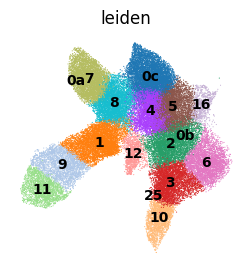

In [ ]:
# load the truncated atlas : shape 49390, 4814
adata = sc.read_h5ad("data/tom_pos.h5ad")
raw_ad = adata.raw.to_adata()

# ery marker

In [ ]:
erythrocyte_markers = {
    "early_progenitors": [
        "Gata1",    # Master erythroid transcription factor
        "Klf1",      # Erythroid Krüppel-like factor (EKLF)
        "Tal1",      # T-cell acute lymphocytic leukemia protein 1 (SCL)
        "Epb4.2"     # Erythrocyte membrane protein band 4.2
    ],
    "intermediate_stages": [
        "Epor",      # Erythropoietin receptor
        "Hbb-b1",    # Hemoglobin subunit beta-1 (adult beta-globin)
        "Hba-a1",    # Hemoglobin subunit alpha-1 (adult alpha-globin)
        "Slc4a1",    # Band 3 (anion exchanger, erythrocyte membrane protein)
        "Gypa",      # Glycophorin A (erythrocyte membrane protein)
        "Ahsp",      # Alpha-hemoglobin stabilizing protein
        "Tfrc"       # Transferrin receptor (iron uptake)
    ],
    "mature_erythrocytes": [
        "Hbb-b1",    # Dominant beta-globin in mature RBCs
        "Hba-a1",    # Dominant alpha-globin in mature RBCs
        "Spna1",     # Alpha-spectrin (cytoskeletal protein)
        "Spnb1",     # Beta-spectrin (cytoskeletal protein)
        "Ank1",      # Ankyrin-1 (links membrane to cytoskeleton)
        "Epb4.2",    # Stabilizes membrane structure
        "Cd47",      # "Don’t eat me" signal to macrophages
        "Ly76"       # TER-119 antigen (cell surface marker)
    ]
}

In [ ]:
with plt.rc_context({"figure.figsize":(3,3), "figure.dpi":100}):
    for k,v in erythrocyte_markers.items():
        plt.suptitle(k)
        genes = np.intersect1d(v, raw_ad.var_names)
        sc.pl.umap(raw_ad, color=genes, legend_loc='on data', frameon=False)